# De Alwis A.A.G. IT22153968 — Logistic Regression

**Dataset:** Titanic Survival  
**Algorithm:** Logistic Regression
**Goal:** Predict whether a passenger survived (1) or not (0)

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
%matplotlib inline


In [2]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
df = pd.read_csv("Titanic_Dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (1309, 14)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [3]:
# ── Explore the Data ─────────────────────────────────────────────────────────
print("=== Column Info ===")
df.info()
print()
print("=== Missing Values ===")
print(df.isnull().sum())
print()
print("=== Survival Count ===")
print(df["survived"].value_counts())


=== Column Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB

=== Missing Values ===
pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
f

In [4]:
# ── Clean the Data ───────────────────────────────────────────────────────────

# 1. Drop columns that are not useful or would cause data leakage
df.drop(columns=["name", "ticket", "cabin", "boat", "body", "home.dest"],
        inplace=True)

# 2. Fill missing values
df["age"]      = df["age"].fillna(df["age"].median())
df["fare"]     = df["fare"].fillna(df["fare"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# 3. Convert Sex to numbers: male=0, female=1
df["sex"] = df["sex"].map({"male": 0, "female": 1})

# 4. Convert Embarked to numbers: S=0, C=1, Q=2
df["embarked"] = df["embarked"].map({"S": 0, "C": 1, "Q": 2})

print("Cleaned dataset shape:", df.shape)
print("Any missing values left?", df.isnull().sum().any())
df.head()


Cleaned dataset shape: (1309, 8)
Any missing values left? False


,pclass,survived,sex,age,sibsp,parch,fare,embarked
0,1,1,1,29.00,0,0,211.3375,0
1,1,1,0,0.92,1,2,151.5500,0
2,1,0,1,2.00,1,2,151.5500,0
3,1,0,0,30.00,1,2,151.5500,0
4,1,0,1,25.00,1,2,151.5500,0


In [5]:
# ── Split into Features (X) and Target (y) ───────────────────────────────────

# X = input columns (what the model learns FROM)
X = df.drop(columns=["survived"])

# y = target column (what the model is PREDICTING)
y = df["survived"]

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")


Training samples : 1047
Testing  samples : 262


In [6]:
# ── Scale the Features ───────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done!")


Scaling done!


In [7]:
# ── Logistic Regression Classifier ───────────────────────────────────────────
# If probability > 0.5  → Predict Survived (1)
# If probability <= 0.5 → Predict Did Not Survive (0)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")


Logistic Regression model trained successfully!


In [8]:
# ── Evaluate the Model ───────────────────────────────────────────────────────
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=["Did Not Survive", "Survived"]))


Accuracy: 78.24%

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.76      0.89      0.82       144
       Survived       0.83      0.65      0.73       118

       accuracy                           0.78       262
      macro avg       0.79      0.77      0.77       262
   weighted avg       0.79      0.78      0.78       262



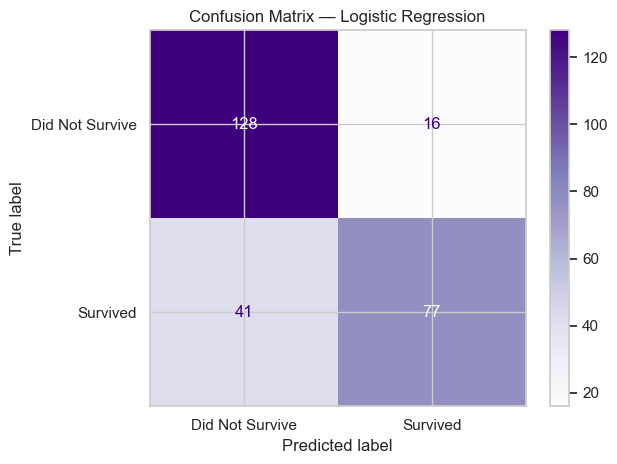

In [9]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Did Not Survive", "Survived"])
disp.plot(cmap="Purples")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()


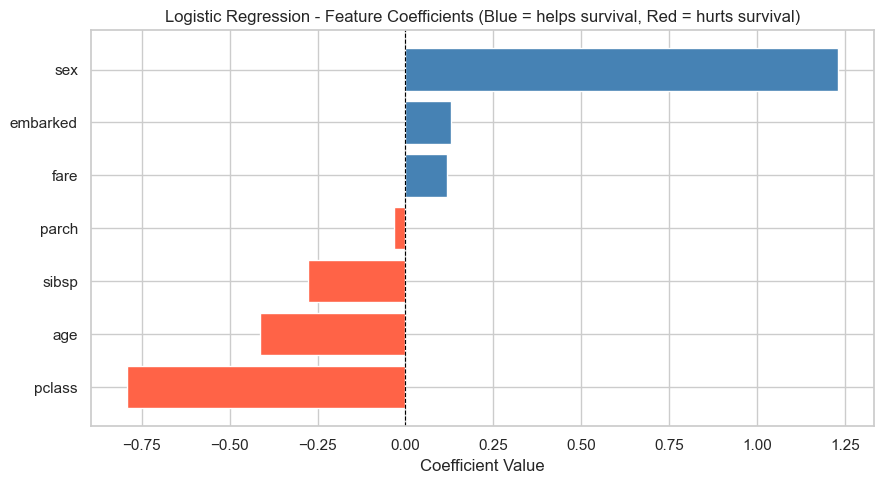

In [10]:
# ── Feature Coefficients ─────────────────────────────────────────────────────
# Coefficients tell us how much each feature influences the prediction.
# Positive value = increases chance of survival
# Negative value = decreases chance of survival

coef_df = pd.DataFrame({
    "Feature"    : X.columns,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient")

colors = ["tomato" if c < 0 else "steelblue" for c in coef_df["Coefficient"]]

plt.figure(figsize=(9, 5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression - Feature Coefficients (Blue = helps survival, Red = hurts survival)")
plt.tight_layout()
plt.show()


In [11]:
# ── Survival Probability Example ─────────────────────────────────────────────
# Logistic Regression can tell us the PROBABILITY of survival, not just Yes/No
# predicted probabilities for the first 10 test passengers

proba = model.predict_proba(X_test_scaled)[:10]
prob_df = pd.DataFrame({
    "Actual"          : y_test.values[:10],
    "Predicted"        : y_pred[:10],
    "Prob (Not Survive)": [round(p[0]*100, 1) for p in proba],
    "Prob (Survive)"   : [round(p[1]*100, 1) for p in proba]
})
print("Survival Probabilities for first 10 test passengers:")
print(prob_df.to_string(index=False))


Survival Probabilities for first 10 test passengers:
 Actual  Predicted  Prob (Not Survive)  Prob (Survive)
      0          0                92.4             7.6
      1          0                89.1            10.9
      0          0                90.7             9.3
      0          0                90.7             9.3
      0          0                86.8            13.2
      1          0                70.8            29.2
      0          0                89.8            10.2
      1          0                80.4            19.6
      0          0                89.0            11.0
      1          1                13.3            86.7


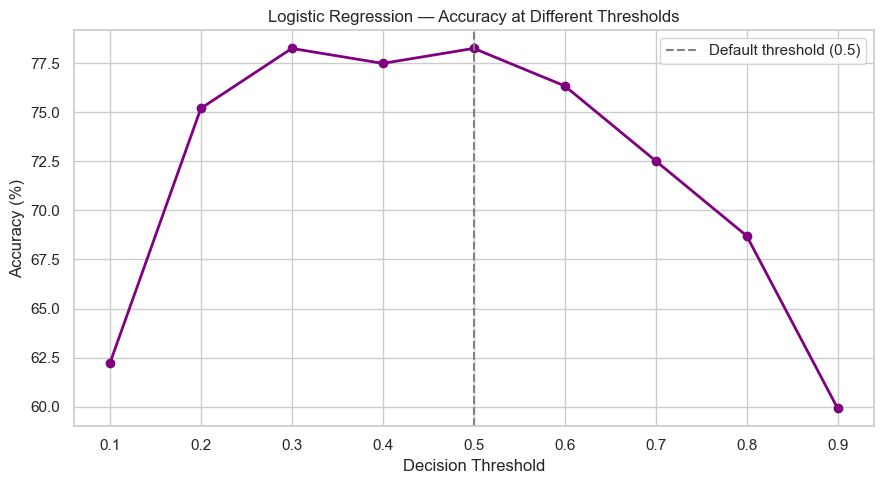

Best threshold = 0.3  →  Accuracy = 78.24%


In [13]:
# ── Effect of Decision Threshold on Accuracy ─────────────────────────────────
# By default the threshold is 0.5 (50% probability = predict survived)
# Here we try different thresholds to see which gives best accuracy

thresholds = [i/10 for i in range(1, 10)]
accs = []

proba_all = model.predict_proba(X_test_scaled)[:, 1]

for t in thresholds:
    preds = (proba_all >= t).astype(int)
    accs.append(accuracy_score(y_test, preds) * 100)

plt.figure(figsize=(9, 5))
plt.plot(thresholds, accs, marker="o", color="purple", linewidth=2)
plt.axvline(0.5, color="gray", linestyle="--", label="Default threshold (0.5)")
plt.xlabel("Decision Threshold")
plt.ylabel("Accuracy (%)")
plt.title("Logistic Regression — Accuracy at Different Thresholds")
plt.legend()
plt.tight_layout()
plt.show()

best_t = thresholds[accs.index(max(accs))]
print(f"Best threshold = {best_t}  →  Accuracy = {max(accs):.2f}%")
